**[Cifar](https://www.cs.toronto.edu/~kriz/cifar.html):
The CIFAR-100 dataset consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images.**

**This dataset is just like the CIFAR-10, except it has 100 classes containing 600 images each. There are 500 training images and 100 testing images per class. The 100 classes in the CIFAR-100 are grouped into 20 superclasses. Each image comes with a "fine" label (the class to which it belongs) and a "coarse" label (the superclass to which it belongs).
Here is the list of classes in the CIFAR-100:**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import tarfile
import tensorflow as tf
from tensorflow import keras
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.exceptions import ConvergenceWarning
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

%matplotlib inline
np.random.seed(1)

warnings.filterwarnings("ignore", category=ConvergenceWarning) 

**Processo de download automático dos dados**

In [20]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data()

In [ ]:
mapping = {
'aquatic mammals': ['beaver', 'dolphin', 'otter', 'seal', 'whale'],
'fish': ['aquarium_fish', 'flatfish', 'ray', 'shark', 'trout'],
'flowers': ['orchid', 'poppy', 'rose', 'sunflower', 'tulip'],
'food containers': ['bottle', 'bowl', 'can', 'cup', 'plate'],
'fruit and vegetables': ['apple', 'mushroom', 'orange', 'pear', 'sweet_pepper'],
'household electrical device': ['clock', 'computer_keyboard', 'lamp', 'telephone', 'television'],
'household furniture': ['bed', 'chair', 'couch', 'table', 'wardrobe'],
'insects': ['bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'],
'large carnivores': ['bear', 'leopard', 'lion', 'tiger', 'wolf'],
'large man-made outdoor things': ['bridge', 'castle', 'house', 'road', 'skyscraper'],
'large natural outdoor scenes': ['cloud', 'forest', 'mountain', 'plain', 'sea'],
'large omnivores and herbivores': ['camel', 'cattle', 'chimpanzee', 'elephant', 'kangaroo'],
'medium-sized mammals': ['fox', 'porcupine', 'possum', 'raccoon', 'skunk'],
'non-insect invertebrates': ['crab', 'lobster', 'snail', 'spider', 'worm'],
'people': ['baby', 'boy', 'girl', 'man', 'woman'],
'reptiles': ['crocodile', 'dinosaur', 'lizard', 'snake', 'turtle'],
'small mammals': ['hamster', 'mouse', 'rabbit', 'shrew', 'squirrel'],
'trees': ['maple_tree', 'oak_tree', 'palm_tree', 'pine_tree', 'willow_tree'],
'vehicles 1': ['bicycle', 'bus', 'motorcycle', 'pickup_truck', 'train'],
'vehicles 2': ['lawn_mower', 'rocket', 'streetcar', 'tank', 'tractor'],
}

str_labels = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 
              'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 
              'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud',
              'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 
              'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 
              'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 
              'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 
              'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum',
              'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 
              'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower',
              'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 
              'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']

In [ ]:
label = ['maçã', 'peixe de aquario', 'bebê', 'Urso', 'Castor', 'cama', 'Abelha', 'besouro', 'bicicleta', 
 'garrafa', 'tigela', 'menino', 'Ponte', 'ônibus', 'borboleta', 'camelo', 'posso', 'castelo', 
 'lagarta', 'gado', 'cadeira', 'chimpanzé', 'relógio', 'nuvem', 'barata', 'sofá', 'cra', 
 'crocodilo', 'copo', 'dinossauro', 'golfinho', 'elefante', 'peixe chato', 'floresta', 'Raposa', 
 'menina', 'hamster', 'lar', 'canguru', 'teclado', 'luminária', 'cortador de grama', 'leopardo', 
 'leão', 'Lagarto', 'lagosta', 'homem', 'ácer', 'motocicleta', 'montanha', 'mouse', 'cogumelo', 
 'Carvalho', 'laranja', 'orquídea', 'lontra', 'Palmeira', 'pera', 'caminhonete', 'Pinheiro', 'plano', 
 'placa', 'papoula', 'porco espinho', 'gambá', 'Coelho', 'guaxinim', 'raio', 'estrada', 'foguete', 
 'Rosa', 'mar', 'foca', 'Tubarão', 'musaranho', 'gamba preto e branco', 'arranha céu', 'lesma', 'cobra', 'aranha', 
 'Esquilo', 'bonde', 'girassol', 'Pimenta Doce', 'tabela', 'tanque', 'Telefone', 'televisão', 'tigre', 
 'trator', 'Comboio', 'truta', 'tulipa', 'tartaruga', 'guarda roupa', 'baleia', 'Salgueiro', 'Lobo', 'mulher', 'verme']

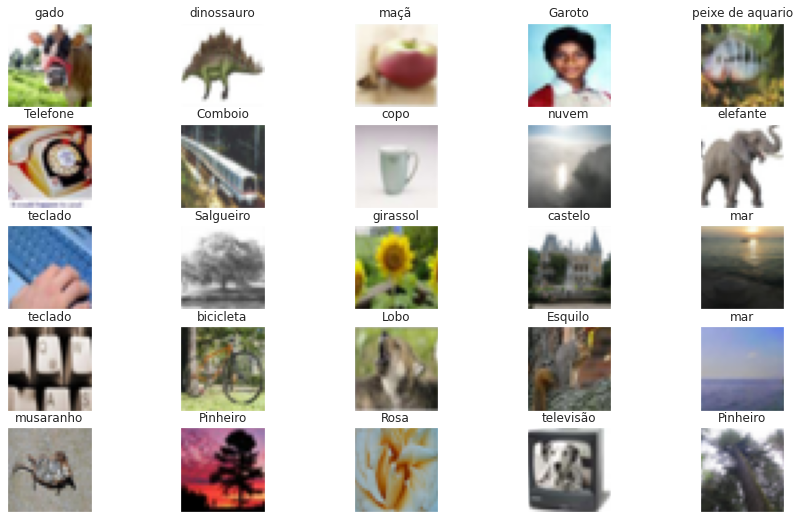

In [22]:
sns.set()
fig, ax = plt.subplots(5,5,figsize=(15,9),subplot_kw={'xticks':(),'yticks':()})
ax = ax.ravel()
for i in range(25):
    ax[i].imshow(x_train[i])
    ax[i].set_title(label[y_train[i][0]])
plt.show()

**Tratamento de dados**

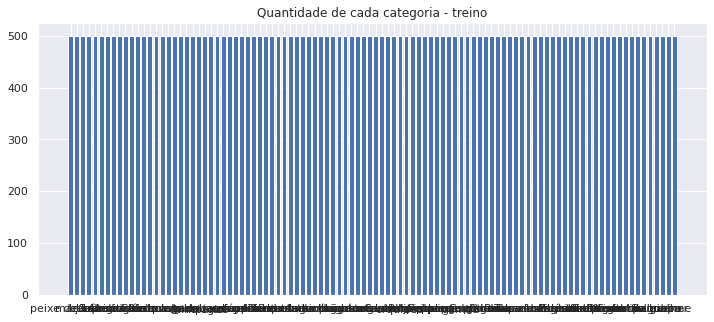

In [23]:
plt.figure(figsize=(12,5))
unicos, contagem = np.unique(y_train, return_counts=True)
plt.bar(label, contagem)
plt.title("Quantidade de cada categoria - treino")
plt.show()

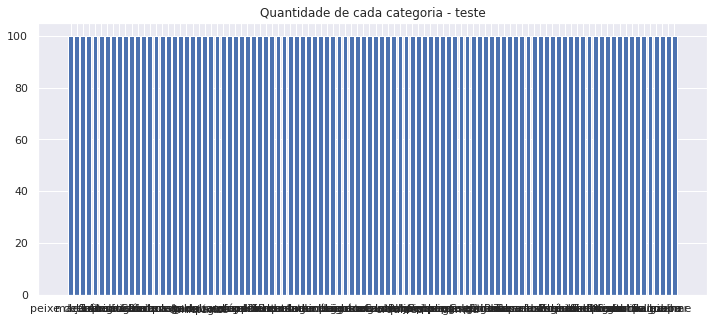

In [24]:
plt.figure(figsize=(12,5))
unicos, contagem = np.unique(y_test, return_counts=True)
plt.bar(label, contagem)
plt.title("Quantidade de cada categoria - teste")
plt.show()

In [25]:
def plotarGrafico(historico,valor1,valor2,valor3,valor4):
    plt.figure(figsize=(10, 8))
    plt.plot(historico.history[valor1])
    plt.plot(historico.history[valor2])
    plt.title(valor3)
    plt.xlabel('Épocas')
    plt.ylabel(valor4)
    plt.legend(['Treino', 'Validação'])
    plt.show()

In [26]:
def prepararDatasetKeras(x_treino, x_teste, y_treino, y_teste):
  x_treino, x_validacao, y_treino, y_validacao = train_test_split(x_treino, y_treino, test_size=0.2)
  
  x_treino = x_treino / 255.
  x_validacao = x_validacao / 255.
  x_teste = x_teste / 255.

  y_treino = y_treino.squeeze()
  y_validacao = y_validacao.squeeze()
  y_teste = y_teste.squeeze()
  
  return x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste

In [27]:
def prepararDatasetScikitLearn(x_treino, x_teste, y_treino, y_teste):
  x_treino, x_validacao, y_treino, y_validacao = train_test_split(x_treino, y_treino, test_size=0.2)
  
  x_treino = (x_treino / 255.).reshape(x_treino.shape[0],-1)
  x_validacao = (x_validacao / 255.).reshape(x_validacao.shape[0],-1)
  x_teste = (x_teste / 255.).reshape(x_teste.shape[0],-1)

  y_treino = y_treino.squeeze()
  y_validacao = y_validacao.squeeze()
  y_teste = y_teste.squeeze()
  
  return x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste

In [28]:
def executarModelo(modelo,x_treino,x_validacao,y_treino,y_validacao,nome):
  treino_erro,validaca_erro = [],[]
  epocas = 100
  melhor_epoca = None
  melhor_modelo = None
  erro_minimo_validacao = float('inf')

  for epoca in range(epocas):
    modelo.fit(x_treino,y_treino) 

    y_treino_resposta = modelo.predict(x_treino)
    y_validacao_resposta = modelo.predict(x_validacao)

    treino_erro.append(mean_squared_error(y_treino,y_treino_resposta,squared=True))
    validaca_erro.append(mean_squared_error(y_validacao,y_validacao_resposta,squared=True))

    if validaca_erro[-1:][0] < erro_minimo_validacao:
      erro_minimo_validacao = validaca_erro[-1:][0]
      melhor_epoca = epoca + 1
      melhor_modelo = modelo

  y_pred = melhor_modelo.predict(x_validacao)

  print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
  print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
  print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')
  print(f"Melhor época: {melhor_epoca}")

  plt.figure(figsize=(12,5))
  plt.title(nome)

  plt.plot(treino_erro)
  plt.plot(validaca_erro)
  plt.title(f'Função de custo vs Número de Épocas - {nome}')
  plt.xlabel('Épocas')
  plt.ylabel("Função de Custo (J)")
  plt.legend(['Treino', 'Validação'])

  plt.show()

  return melhor_modelo

Acurácia do modelo na validação com melhor modelo é 17.44%.
Precisão do modelo na validação com melhor modelo é 17.44%.
Recall do modelo na validação com melhor modelo é 17.44%.
Melhor época: 11


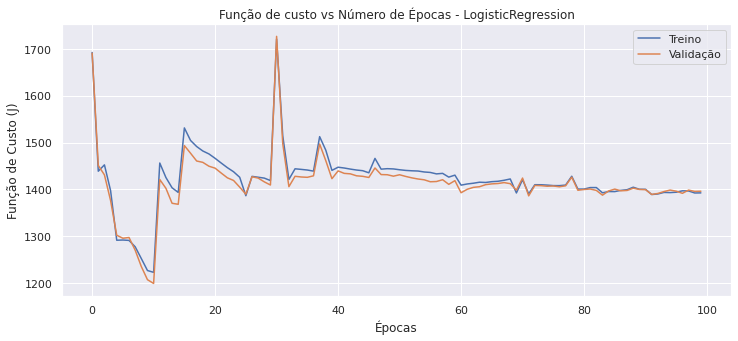

In [29]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetScikitLearn(x_train, x_test, y_train, y_test)

modelo = executarModelo(LogisticRegression(solver="lbfgs", max_iter = 1,warm_start=True, multi_class="multinomial"),x_treino,x_validacao,y_treino,y_validacao,'LogisticRegression')

filename = 'modelo1.sav'
pickle.dump(modelo, open(filename, 'wb'))

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_3 (Flatten)         (None, 3072)              0         
                                                                 
 dense_9 (Dense)             (None, 300)               921900    
                                                                 
 dense_10 (Dense)            (None, 100)               30100     
                                                                 
 dense_11 (Dense)            (None, 100)               10100     
                                                                 
Total params: 962,100
Trainable params: 962,100
Non-trainable params: 0
_________________________________________________________________
Epoch 1/15
157/157 [==============================] - 62s 43ms/step - loss: 4.6157 - accuracy: 0.0370 - val_loss: 4.3671 - val_accuracy: 0.0670
Epoch 2/15
157/157 [================

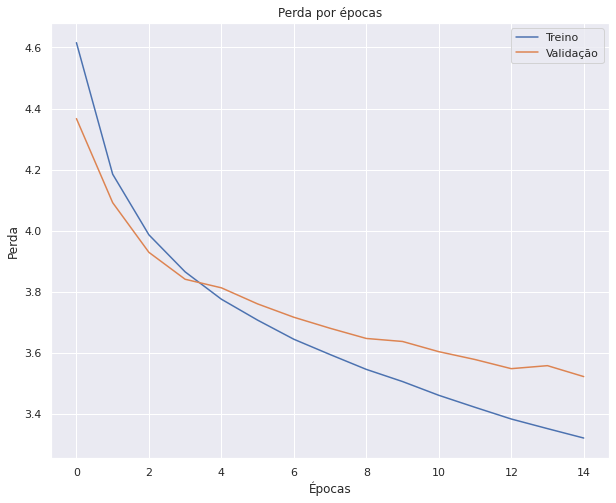

Acurácia do modelo na validação com melhor modelo é 21.31%.
Precisão do modelo na validação com melhor modelo é 21.31%.
Recall do modelo na validação com melhor modelo é 21.31%.


In [33]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

tamanho_batch = 256
epocas = 15
nome = 'modelo1.h5'

checkpoint = keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)
early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
callbacks= [checkpoint,early]

kernel_initializer = tf.keras.initializers.GlorotUniform(seed=None)
bias_initializer = tf.keras.initializers.Ones()
regularizer = tf.keras.regularizers.l2(1e-4)

modelo = keras.Sequential(
    [
        keras.Input(shape=(32,32,3,)),
        layers.Flatten(),
        layers.Dense(300, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dense(100, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dense(100, activation="softmax", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04, beta_1=0.9, beta_2=0.999, epsilon=1e-07), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = modelo.predict(x_validacao)
y_pred = np.argmax(y_pred, axis=1)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_4 (Flatten)         (None, 3072)              0         
                                                                 
 dense_12 (Dense)            (None, 300)               921900    
                                                                 
 dropout_2 (Dropout)         (None, 300)               0         
                                                                 
 dense_13 (Dense)            (None, 100)               30100     
                                                                 
 dropout_3 (Dropout)         (None, 100)               0         
                                                                 
 dense_14 (Dense)            (None, 100)               10100     
                                                                 
Total params: 962,100
Trainable params: 962,100
Non-tr

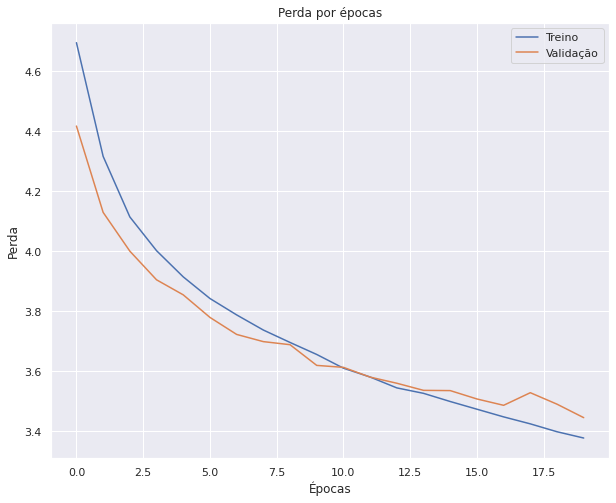

Acurácia do modelo na validação com melhor modelo é 21.66%.
Precisão do modelo na validação com melhor modelo é 21.66%.
Recall do modelo na validação com melhor modelo é 21.66%.


In [34]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

tamanho_batch = 256
epocas = 20
nome = 'modelo2.h5'

checkpoint = keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)
early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
callbacks= [checkpoint,early]

kernel_initializer = tf.keras.initializers.GlorotUniform(seed=None)
bias_initializer = tf.keras.initializers.Ones()
regularizer = tf.keras.regularizers.l2(1e-4)

modelo = keras.Sequential(
    [
        keras.Input(shape=(32,32,3,)),
        layers.Flatten(),
        layers.Dense(300, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dropout(0.1),
        layers.Dense(100, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dropout(0.1),
        layers.Dense(100, activation="softmax", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04, beta_1=0.9, beta_2=0.999, epsilon=1e-07), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = modelo.predict(x_validacao)
y_pred = np.argmax(y_pred, axis=1)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

In [ ]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

tamanho_batch = 256
epocas = 20
nome = 'modelo3.h5'

checkpoint = keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)
early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
callbacks= [checkpoint,early]

kernel_initializer = tf.keras.initializers.GlorotUniform(seed=None)
bias_initializer = tf.keras.initializers.Ones()
regularizer = tf.keras.regularizers.l2(1e-4)

modelo = keras.Sequential(
    [
        keras.Input(shape=(32,32,3,)),
     
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),
     
        layers.Flatten(),
        layers.Dense(128, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(100, activation="softmax", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04, beta_1=0.9, beta_2=0.999, epsilon=1e-07), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = modelo.predict(x_validacao)
y_pred = np.argmax(y_pred, axis=1)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

In [ ]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

tamanho_batch = 256
epocas = 20
nome = 'modelo4.h5'

checkpoint = keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)
early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
callbacks= [checkpoint,early]

kernel_initializer = tf.keras.initializers.GlorotUniform(seed=None)
bias_initializer = tf.keras.initializers.Ones()
regularizer = tf.keras.regularizers.l2(1e-4)

# Carregamento do modelo pré-treinado SEM as camadas densas (include_top = False)
vgg16 = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3,))

# Congela camadas pré-treinadas
for layer in vgg16.layers:
  layer.trainable = False

modelo = keras.Sequential(
    [
        vgg16,
        layers.GlobalAveragePooling2D(),
        layers.Dense(100, activation="softmax", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04, beta_1=0.9, beta_2=0.999, epsilon=1e-07), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = modelo.predict(x_validacao)
y_pred = np.argmax(y_pred, axis=1)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

In [ ]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

tamanho_batch = 256
epocas = 20
nome = 'modelo5.h5'

checkpoint = keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)
early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
callbacks= [checkpoint,early]

kernel_initializer = tf.keras.initializers.GlorotUniform(seed=None)
bias_initializer = tf.keras.initializers.Ones()
regularizer = tf.keras.regularizers.l2(1e-4)

# Carregamento do modelo pré-treinado SEM as camadas densas (include_top = False)
vgg16 = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3,))

# Descongela camadas pré-treinadas
for layer in vgg16.layers:
  layer.trainable = True

modelo = keras.Sequential(
    [
        vgg16,
        layers.GlobalAveragePooling2D(),
        layers.Dense(100, activation="softmax", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04, beta_1=0.9, beta_2=0.999, epsilon=1e-07), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = modelo.predict(x_validacao)
y_pred = np.argmax(y_pred, axis=1)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

In [ ]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

tamanho_batch = 256
epocas = 20
nome = 'modelo6.h5'

checkpoint = keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)
early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
callbacks= [checkpoint,early]

kernel_initializer = tf.keras.initializers.GlorotUniform(seed=None)
bias_initializer = tf.keras.initializers.Ones()
regularizer = tf.keras.regularizers.l2(1e-4)

# Carregamento do modelo pré-treinado SEM as camadas densas (include_top = False)
vgg16 = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3,))

# Descongela camadas pré-treinadas
for layer in vgg16.layers:
  layer.trainable = True

modelo = keras.Sequential(
    [
        vgg16,
        #layers.GlobalAveragePooling2D(),
        layers.Flatten(),
        layers.Dense(4096, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dense(4096, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dense(100, activation="softmax", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04, beta_1=0.9, beta_2=0.999, epsilon=1e-07), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = modelo.predict(x_validacao)
y_pred = np.argmax(y_pred, axis=1)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

In [ ]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

extrator = keras.models.load_model('modelo6.h5')
extrator = Model(inputs=extrator.input, outputs=extrator.get_layer('dense_5').output)

x_extrator_validacao = extrator.predict(x_validacao)
x_extrator_treino = extrator.predict(x_treino)

modelo = LogisticRegression()
modelo.fit(x_extrator_treino, y_treino)

filename = 'modelo7.sav'
pickle.dump(modelo, open(filename, 'wb'))

y_pred = modelo.predict(x_extrator_validacao)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

In [ ]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

extrator = keras.models.load_model('modelo6.h5')
extrator = Model(inputs=extrator.input, outputs=extrator.get_layer('dense_5').output)

x_extrator_validacao = extrator.predict(x_validacao)
x_extrator_treino = extrator.predict(x_treino)

modelo = SVC()
modelo.fit(x_extrator_treino, y_treino)

filename = 'modelo8.sav'
pickle.dump(modelo, open(filename, 'wb'))

y_pred = modelo.predict(x_extrator_validacao)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

In [ ]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

extrator = keras.models.load_model('modelo6.h5')
extrator = Model(inputs=extrator.input, outputs=extrator.get_layer('dense_5').output)

x_extrator_validacao = extrator.predict(x_validacao)
x_extrator_treino = extrator.predict(x_treino)

modelo = RandomForestClassifier()
modelo.fit(x_extrator_treino, y_treino)

filename = 'modelo9.sav'
pickle.dump(modelo, open(filename, 'wb'))

y_pred = modelo.predict(x_extrator_validacao)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')